In [2]:
!pip install pygraphviz

  Using cached pygraphviz-1.14.tar.gz (106 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [102 lines of output]
      /private/var/folders/kv/9b0l8lv56tsc3yvfy9l9nq180000gn/T/pip-build-env-414cj51a/overlay/lib/python3.11/site-packages/setuptools/config/_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2027-Feb-18, you need to update your project and remove deprecated calls
              or 

In [3]:
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage , AIMessage , HumanMessage
from langgraph.graph import END, MessageGraph, StateGraph
from typing import List , Sequence
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder

In [4]:
api_key = "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"


In [5]:
meta_llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    groq_api_key = api_key,
    temperature = 0.7,
    max_tokens = 512
)
open_ai_llm = ChatGroq(
    model = "openai/gpt-oss-120b",
    groq_api_key = api_key,
    temperature = 0.3,
    max_tokens = 512
)

In [6]:
#Generating the prompts
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name = "messages")
    ]
)

In [7]:
generate_chain = generation_prompt | meta_llm

In [8]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
        ),
        MessagesPlaceholder(variable_name = "messages")
    ]
)

In [9]:
reflect_chain = reflection_prompt | open_ai_llm

In [10]:
from langgraph.graph import MessageGraph
graph = MessageGraph()

/var/folders/kv/9b0l8lv56tsc3yvfy9l9nq180000gn/T/ipykernel_67783/2804684331.py:2: LangGraphDeprecatedSinceV10: MessageGraph is deprecated in LangGraph v1.0.0, to be removed in v2.0.0. Please use StateGraph with a `messages` key instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = MessageGraph()


In [11]:
def generation_node(state:Sequence[BaseMessage]):
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content = generated_post.content)]

In [12]:
def reflection_node(state:Sequence[BaseMessage]):
    reflected_post = reflect_chain.invoke({"messages": state})
    return [HumanMessage(content = reflected_post.content)]

In [13]:
graph.add_node("generate",generation_node)
graph.add_node("reflect",reflection_node)

In [14]:
graph.add_edge("reflect" , "generate")

In [15]:
graph.set_entry_point("generate")

In [16]:
def should_continue(state: List[BaseMessage]):
    print(state)
    print(len(state))
    print("----------------------------------------------------------------------")
    if len(state) > 6:
        return END
    return "reflect"

In [17]:
graph.add_conditional_edges("generate",should_continue)

In [18]:
workflow = graph.compile()

In [19]:
inputs = HumanMessage(content="""Write a linkedin post on getting a software developer job at IBM under 160 characters""")

In [20]:
response = workflow.invoke(inputs)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='c95ba90e-5ee6-4adc-80e4-bb94cf27d4dd'), AIMessage(content='"Land a dev role at IBM! Build skills, network & tailor your resume to stand out" #IBMCareers #SoftwareDeveloper', additional_kwargs={}, response_metadata={}, id='9e52d9ed-be0b-4827-91b7-1d4db67a9706', tool_calls=[], invalid_tool_calls=[])]
2
----------------------------------------------------------------------
[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='c95ba90e-5ee6-4adc-80e4-bb94cf27d4dd'), AIMessage(content='"Land a dev role at IBM! Build skills, network & tailor your resume to stand out" #IBMCareers #SoftwareDeveloper', additional_kwargs={}, response_metadata={}, id='9e52d9ed-be0b-4827-91b7-1d4db67a9706', tool_calls=[], invalid_tool_calls=[]), HumanMess

In [21]:
for i in range(0,len(response)):
    print(response[i].content)

Write a linkedin post on getting a software developer job at IBM under 160 characters
"Land a dev role at IBM! Build skills, network & tailor your resume to stand out" #IBMCareers #SoftwareDeveloper
I’m happy to help you fine‑tune a LinkedIn post, but I’ll need the specific draft you’d like critiqued. Could you please share the exact text (or a screenshot) of the post you want evaluated? Once I have it, I’ll provide a detailed, actionable critique based on LinkedIn best practices.
Here's the exact text of the LinkedIn post I'd like you to critique:

"Land a dev role at IBM! Build skills, network & tailor your resume to stand out #IBMCareers #SoftwareDeveloper"

Please provide your feedback on clarity, tone, engagement, and overall effectiveness, and I'll refine it accordingly.
**Critique of the LinkedIn Post**

> “Land a dev role at IBM! Build skills, network & tailor your resume to stand out #IBMCareers #SoftwareDeveloper”

---

## 1. Overall Quality & Professionalism  
**Score: 6 / 1

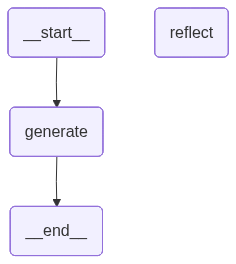

In [25]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))